In [1]:
!pip install harmonypy=='0.0.9'

In [2]:
!pip install anndata=='0.8.0'

In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
import anndata as ad
from sklearn.manifold import TSNE

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#input: combined h5ad of data
#output: SAM object

In [2]:
fn = '../../Testing_Raw_Dat_RNASEQ_Joined/AC_08252026_cleaned.h5ad'

In [3]:
dataframe = sc.read_h5ad(fn)

In [4]:
#if rerunning on something that has already been normalized in the past
dataframe.X = dataframe.obsm['Raw_X']

KeyError: 'Raw_X'

In [4]:
for item in dataframe.X[0,:]:
    print(item)

  (0, 12994)	1.0
  (0, 16388)	1.0
  (0, 159)	1.0
  (0, 21397)	2.0
  (0, 13319)	1.0
  (0, 15683)	1.0
  (0, 11423)	1.0
  (0, 17008)	1.0
  (0, 13480)	2.0
  (0, 19082)	2.0
  (0, 13794)	1.0
  (0, 16939)	1.0
  (0, 19966)	1.0
  (0, 6977)	1.0
  (0, 11196)	1.0
  (0, 21226)	1.0
  (0, 11216)	3.0
  (0, 18784)	1.0
  (0, 7028)	1.0
  (0, 10834)	1.0
  (0, 18847)	1.0
  (0, 14182)	1.0
  (0, 12534)	3.0
  (0, 14385)	1.0
  (0, 21959)	1.0
  :	:
  (0, 10418)	1.0
  (0, 11667)	1.0
  (0, 12344)	1.0
  (0, 5816)	1.0
  (0, 13815)	1.0
  (0, 2225)	1.0
  (0, 13273)	1.0
  (0, 22872)	1.0
  (0, 10343)	1.0
  (0, 21642)	1.0
  (0, 15692)	3.0
  (0, 20068)	1.0
  (0, 19564)	1.0
  (0, 20512)	1.0
  (0, 18524)	1.0
  (0, 23542)	1.0
  (0, 6017)	2.0
  (0, 20023)	1.0
  (0, 23592)	1.0
  (0, 1404)	1.0
  (0, 6112)	1.0
  (0, 10341)	1.0
  (0, 6120)	1.0
  (0, 6149)	1.0
  (0, 6175)	1.0


In [5]:
dataframe.X

<50532x23671 sparse matrix of type '<class 'numpy.float32'>'
	with 76811207 stored elements in Compressed Sparse Row format>

In [ ]:
#Make sure gene names are in BLAST Table

In [9]:
mapping = pd.read_csv('../../BLASTMAPPING/maps/active_maps/hypo_proj/mgac/mg_to_ac.txt', delimiter = '\t', header = None)

In [10]:
gene_set = set(mapping[1])

In [11]:
a = 0
for item in dataframe.var_names:
    if item in gene_set:
        a += 1
a 

18826

In [ ]:
#Check whether the data is "raw" (UMI counts)

In [12]:
print(dataframe.X[10,:])

  (0, 13030)	1.0
  (0, 16388)	1.0
  (0, 3978)	1.0
  (0, 13205)	1.0
  (0, 13426)	1.0
  (0, 13319)	1.0
  (0, 15683)	1.0
  (0, 18442)	1.0
  (0, 22989)	1.0
  (0, 11423)	2.0
  (0, 20004)	1.0
  (0, 17674)	2.0
  (0, 14030)	2.0
  (0, 10546)	2.0
  (0, 16354)	1.0
  (0, 10093)	1.0
  (0, 21237)	1.0
  (0, 13399)	1.0
  (0, 11216)	4.0
  (0, 3510)	1.0
  (0, 18784)	1.0
  (0, 16235)	1.0
  (0, 16652)	1.0
  (0, 9960)	2.0
  (0, 13661)	1.0
  :	:
  (0, 10746)	1.0
  (0, 21644)	1.0
  (0, 19905)	1.0
  (0, 19028)	1.0
  (0, 13198)	1.0
  (0, 19224)	1.0
  (0, 10343)	1.0
  (0, 21642)	1.0
  (0, 15692)	3.0
  (0, 5886)	1.0
  (0, 12041)	1.0
  (0, 11468)	1.0
  (0, 17532)	1.0
  (0, 19564)	1.0
  (0, 20512)	1.0
  (0, 23348)	1.0
  (0, 15525)	2.0
  (0, 6017)	1.0
  (0, 21745)	1.0
  (0, 13243)	1.0
  (0, 19251)	1.0
  (0, 14187)	1.0
  (0, 15289)	1.0
  (0, 16864)	1.0
  (0, 1144)	2.0


In [ ]:
#Check number of counts/genes

In [13]:
statistics.median(dataframe.obs['n_genes'])

1413.0

In [ ]:
#plotting n_genes

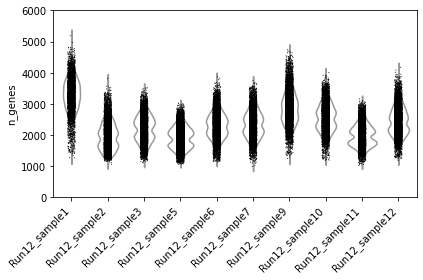

In [11]:
from matplotlib import rcParams

plt.rcParams['figure.figsize'] = 20,10
sns.reset_orig()
sns.violinplot(x = 'key', y = 'n_genes', data = dataframe.obs, color = 'white')
sns.stripplot(x = 'key', y = 'n_genes', data = dataframe.obs, color = 'black', size = 1)
plt.xticks(rotation=45, ha = 'right')
plt.ylim((0,6000))
plt.xlabel(None)
plt.tight_layout()
plt.savefig(fn + '_ngenes.png')
plt.show()

In [ ]:
#plotting n counts

In [ ]:
from matplotlib import rcParams

rcParams['figure.figsize'] = 20,10
sns.reset_orig()
sns.violinplot(x = 'key', y = 'n_counts', data = dataframe.obs, color = 'white')
sns.stripplot(x = 'key', y = 'n_counts', data = dataframe.obs, color = 'black', size = 1)
plt.xticks(rotation=45, ha = 'right')
plt.ylim((0,22000))
plt.xlabel(None)
plt.tight_layout()
plt.savefig(fn + '_ncounts.png')
plt.show()

In [ ]:
#extra make unique

In [14]:
dataframe.obs_names_make_unique()
dataframe.var_names_make_unique()

In [56]:
#subset dataframe (only if needed)

In [15]:
sam=SAM(dataframe)
sam.preprocess_data() #log transforms and filters the data
sam.run(batch_key='key') #run with default parameters

RUNNING SAM
Iteration: 0, Convergence: 1.0


2026-08-27 00:37:50,119 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-08-27 00:38:09,815 - harmonypy - INFO - sklearn.KMeans initialization complete.


Iteration: 1, Convergence: 0.8234738370270783


2026-08-27 00:39:25,677 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-08-27 00:39:44,001 - harmonypy - INFO - sklearn.KMeans initialization complete.


Iteration: 2, Convergence: 0.013448413130509465


2026-08-27 00:41:02,412 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-08-27 00:41:20,337 - harmonypy - INFO - sklearn.KMeans initialization complete.


Computing the UMAP embedding...
Elapsed time: 356.7566797733307 seconds


In [16]:
sam.adata.uns['Batchcorr'] = 'HarmonyPy'

In [17]:
sam.adata.uns

OverloadedDict, wrapping:
	{'qc_removed_clusters': array(['38'], dtype=object), 'qc_removed_n_cells': 421, 'qc_source_sam': '../Active_SAM_joined/SAM_AC_soupx_ncbi_08242026.h5ad', 'preprocess_args': {'div': 1, 'sum_norm': 'cell_median', 'norm': 'log', 'min_expression': 1, 'thresh_low': 0.0, 'thresh_high': 0.96, 'filter_genes': True}, 'run_args': {'max_iter': 10, 'verbose': True, 'projection': 'umap', 'stopping_condition': 0.01, 'num_norm_avg': 50, 'k': 20, 'distance': 'cosine', 'preprocessing': 'StandardScaler', 'npcs': 150, 'n_genes': 3000, 'weight_PCs': False, 'proj_kwargs': {}, 'sparse_pca': False, 'weight_mode': 'rms', 'seed': 0, 'components': None}, 'dimred_indices': array([    4,    16,    88, ..., 23635, 23653, 23660]), 'ranked_genes': array(['mbp', 'adarb2', 'cldn11', ..., 'LOC134299252', 'LOC134299475',
       'LOC100337544'], dtype='<U12'), 'Batchcorr': 'HarmonyPy'}
With overloaded keys:
	['neighbors'].

In [ ]:
#save raw counts in obsm

In [19]:
sam.adata.obsm['Raw_X'] = dataframe.X

In [20]:
sam.save_anndata('../../Active_SAM_joined/SAM_AC_soupx_ncbi_cleaned_08262026.h5ad')